# Black-Scholes Model — Commodity Trading Cheat Sheet

Covers the BSM formula from first principles, how it extends to commodity markets via the **Black-76** model, and where the standard model breaks down for physical commodities.

---

## Setup

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm
from scipy.optimize import brentq

# ── Black-Scholes (equity style) ────────────────────────────────────────────
def d1_bs(S, K, T, r, sigma):
    return (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))

def d2_bs(S, K, T, r, sigma):
    return d1_bs(S, K, T, r, sigma) - sigma * np.sqrt(T)

def bs_call(S, K, T, r, sigma):
    d1, d2 = d1_bs(S,K,T,r,sigma), d2_bs(S,K,T,r,sigma)
    return S * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)

def bs_put(S, K, T, r, sigma):
    d1, d2 = d1_bs(S,K,T,r,sigma), d2_bs(S,K,T,r,sigma)
    return K * np.exp(-r*T) * norm.cdf(-d2) - S * norm.cdf(-d1)

# ── Black-76 (futures / commodity options) ──────────────────────────────────
def d1_76(F, K, T, r, sigma):
    return (np.log(F / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))

def d2_76(F, K, T, r, sigma):
    return d1_76(F, K, T, r, sigma) - sigma * np.sqrt(T)

def black76_call(F, K, T, r, sigma):
    d1, d2 = d1_76(F,K,T,r,sigma), d2_76(F,K,T,r,sigma)
    return np.exp(-r*T) * (F * norm.cdf(d1) - K * norm.cdf(d2))

def black76_put(F, K, T, r, sigma):
    d1, d2 = d1_76(F,K,T,r,sigma), d2_76(F,K,T,r,sigma)
    return np.exp(-r*T) * (K * norm.cdf(-d2) - F * norm.cdf(-d1))

# ── Implied volatility (Black-76) ────────────────────────────────────────────
def implied_vol_76(price, F, K, T, r, option_type='call'):
    fn = black76_call if option_type == 'call' else black76_put
    try:
        return brentq(lambda s: fn(F, K, T, r, s) - price, 1e-6, 10.0)
    except ValueError:
        return np.nan

print("Ready.")

Ready.


---
## 1. Black-Scholes Model — First Principles

### 1.1 The Core Assumptions

| Assumption | Reality check for commodities |
|---|---|
| Underlying follows **geometric Brownian motion** (log-normal returns) | Commodities have jumps, seasonality, mean-reversion — often violated |
| **Constant volatility** over the option's life | Commodity vol is highly seasonal and state-dependent |
| **No dividends** (or known continuous dividend yield) | Commodities have storage costs and convenience yield instead |
| **Continuous trading**, no transaction costs | Reasonable approximation for liquid futures markets |
| **Constant risk-free rate** | Minor violation; acceptable |
| **European exercise only** | Many commodity options are American; requires adjustment |

### 1.2 The BSM Formula

For a **European call** on a non-dividend-paying stock:

$$C = S \cdot N(d_1) - K e^{-rT} \cdot N(d_2)$$

$$P = K e^{-rT} \cdot N(-d_2) - S \cdot N(-d_1)$$

$$d_1 = \frac{\ln(S/K) + (r + \frac{1}{2}\sigma^2)T}{\sigma\sqrt{T}} \qquad d_2 = d_1 - \sigma\sqrt{T}$$

**Intuition:**
- $S \cdot N(d_1)$ — the expected value of receiving the stock (probability-weighted), discounted
- $K e^{-rT} \cdot N(d_2)$ — the present value of paying the strike, weighted by probability of exercise
- $N(d_2)$ ≈ risk-neutral probability that the option expires in-the-money

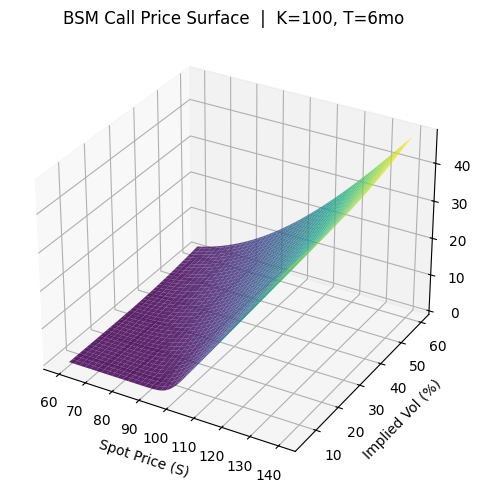

In [3]:
# BSM price surface: call price as function of spot and vol
S_vals    = np.linspace(60, 140, 80)
sigma_vals = np.linspace(0.05, 0.60, 80)
SS, VV = np.meshgrid(S_vals, sigma_vals)

K, T, r = 100, 0.5, 0.05
call_surface = bs_call(SS, K, T, r, VV)

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(SS, VV * 100, call_surface, cmap='viridis', alpha=0.85)
ax.set_xlabel('Spot Price (S)')
ax.set_ylabel('Implied Vol (%)')
ax.set_zlabel('Call Price ($)')
ax.set_title('BSM Call Price Surface  |  K=100, T=6mo')
plt.tight_layout()
plt.show()

---
## 2. Cost-of-Carry Model — Bridging BSM to Commodities

For a commodity held in inventory, the forward/futures price embeds the **cost-of-carry**:

$$F = S \cdot e^{(r + s - c)T}$$

| Variable | Meaning |
|---|---|
| $S$ | Spot price |
| $r$ | Risk-free rate |
| $s$ | Storage cost rate (% per year) |
| $c$ | Convenience yield (% per year) — the premium of holding physical inventory |
| $F$ | Futures price |

### Contango vs. Backwardation

| Market State | Condition | Who it favors |
|---|---|---|
| **Contango** | F > S · e^(rT): futures > spot | Sellers of physical (can store and sell forward at premium) |
| **Backwardation** | F < S · e^(rT): futures < spot | Holders of physical (convenience yield > carry costs) |
| **Full carry** | F = S · e^((r+s)T) | Storage is fully compensated, convenience yield ≈ 0 |

**Commodity-specific patterns:**
- **Crude oil:** frequently in contango; storage is feasible and costly
- **Natural gas:** seasonal contango (summer→winter injection) then backwardation (winter withdrawal)
- **Agricultural (wheat, corn):** post-harvest contango → pre-harvest backwardation
- **Gold/Silver:** nearly always in contango (low storage costs, no consumption convenience yield)
- **Copper:** backwardation signals physical tightness (supply crunch)

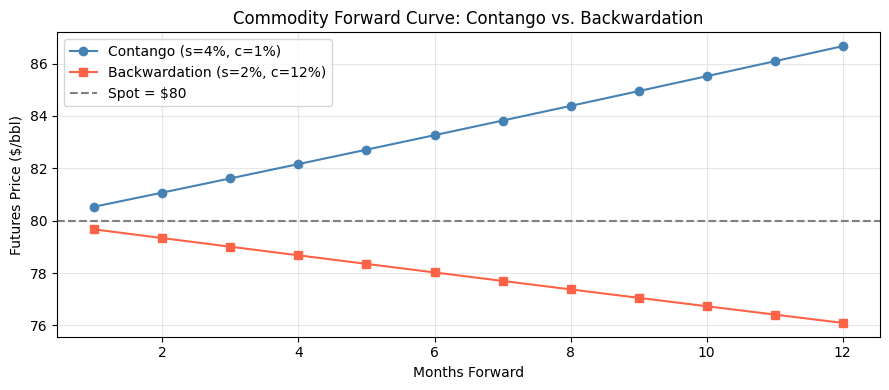

In [4]:
T_months = np.arange(1, 13)
T_years  = T_months / 12
S0 = 80   # spot price (e.g., crude oil $/bbl)
r  = 0.05

# Contango scenario: storage > convenience yield
s_contango, c_contango = 0.04, 0.01
F_contango = S0 * np.exp((r + s_contango - c_contango) * T_years)

# Backwardation scenario: high convenience yield
s_back, c_back = 0.02, 0.12
F_back = S0 * np.exp((r + s_back - c_back) * T_years)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(T_months, F_contango, 'o-', color='steelblue',  label='Contango (s=4%, c=1%)')
ax.plot(T_months, F_back,    's-', color='tomato',     label='Backwardation (s=2%, c=12%)')
ax.axhline(S0, color='gray', linestyle='--', label=f'Spot = ${S0}')
ax.set_xlabel('Months Forward')
ax.set_ylabel('Futures Price ($/bbl)')
ax.set_title('Commodity Forward Curve: Contango vs. Backwardation')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 3. Black-76 Model — BSM for Commodity Futures Options

Fischer Black (1976) adapted BSM to price **options on futures contracts**. This is the industry standard for commodity options.

### Why not plain BSM?
- Commodity options are typically written on **futures**, not spot
- The futures price $F$ is directly observable and accounts for storage costs and convenience yield
- You don't need to model carry separately — it's already baked into $F$

### The Black-76 Formula

$$C = e^{-rT} \left[ F \cdot N(d_1) - K \cdot N(d_2) \right]$$

$$P = e^{-rT} \left[ K \cdot N(-d_2) - F \cdot N(-d_1) \right]$$

$$d_1 = \frac{\ln(F/K) + \frac{1}{2}\sigma^2 T}{\sigma\sqrt{T}} \qquad d_2 = d_1 - \sigma\sqrt{T}$$

**Key differences from BSM:**
- Replace spot $S$ with futures price $F$ everywhere
- No $r$ term inside $d_1$ (futures are already a "free" position — no cost of carry at initiation)
- Both $d_1$ and $d_2$ are discounted by $e^{-rT}$ (the settlement is at expiry)

**Where it's used:**
- Crude oil options (WTI, Brent)
- Natural gas options (Henry Hub)
- Agricultural options (CBOT corn, wheat, soybeans)
- Metals options (COMEX gold, copper)
- Interest rate caps/floors (same math, different context)

In [5]:
# Compare BSM vs Black-76 on the same scenario
K, T, r, sigma = 100, 0.5, 0.05, 0.30
S0 = 100
# Futures price under full carry (no convenience yield, small storage)
F0 = S0 * np.exp((r + 0.02) * T)  # ~F > S in contango

print(f"Spot S = {S0:.2f}   Futures F = {F0:.2f}")
print(f"K = {K}, T = {T}yr, r = {r*100:.0f}%, σ = {sigma*100:.0f}%")
print()
print(f"BSM   call = {bs_call(S0, K, T, r, sigma):.4f}")
print(f"B-76  call = {black76_call(F0, K, T, r, sigma):.4f}")
print()
print(f"BSM   put  = {bs_put(S0, K, T, r, sigma):.4f}")
print(f"B-76  put  = {black76_put(F0, K, T, r, sigma):.4f}")
print()
print("Note: prices differ because B-76 is on the futures price,")
print("which already reflects carry. In backwardation F < S,")
print("so B-76 calls would be cheaper and puts more expensive.")

Spot S = 100.00   Futures F = 103.56
K = 100, T = 0.5yr, r = 5%, σ = 30%

BSM   call = 9.6349
B-76  call = 10.2356

BSM   put  = 7.1659
B-76  put  = 6.7616

Note: prices differ because B-76 is on the futures price,
which already reflects carry. In backwardation F < S,
so B-76 calls would be cheaper and puts more expensive.


---
## 4. Implied Volatility in Commodity Markets

### 4.1 What IV Means for Commodities

Implied vol is the market's **consensus forecast of future price uncertainty**, backed out from observed option prices using Black-76.

| Market | Typical IV Range | Key Drivers of IV Spikes |
|---|---|---|
| WTI Crude Oil | 25–60% | OPEC cuts, geopolitical events, demand shocks |
| Natural Gas | 40–150% | Weather forecasts, storage reports, LNG export disruptions |
| Corn / Soybeans | 20–50% | USDA crop reports, planting season, La Niña/El Niño |
| Gold | 10–25% | Fed policy, USD moves, risk-off sentiment |
| Copper | 20–40% | China PMI, global manufacturing demand |

### 4.2 The Volatility Smile / Skew in Commodities

BSM assumes flat IV across strikes. In reality, commodity IV surfaces have pronounced **skew**:

- **Energy (crude, gas):** upside skew — OTM calls are expensive relative to puts. Supply disruptions cause spikes (price can double; can't go below zero)
- **Agricultural:** upside skew pre-harvest; can flatten post-harvest once supply is known
- **Gold:** near-flat or mild upside skew (safe-haven demand drives call premium)
- **Base metals (copper):** downside skew — demand crashes (China slowdown) are feared more than supply squeezes

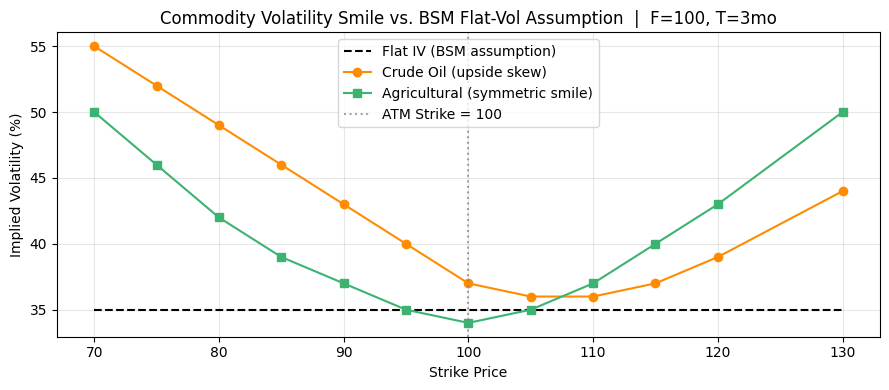

In [6]:
# Illustrate a commodity vol smile vs. flat BSM assumption
strikes = np.array([70, 75, 80, 85, 90, 95, 100, 105, 110, 115, 120, 130])
F_spot  = 100
T, r    = 0.25, 0.05

# Flat BSM vol (what BSM assumes)
flat_iv = np.full_like(strikes, 0.35, dtype=float)

# Crude oil smile: upside skew (OTM calls expensive)
crude_iv = np.array([0.55, 0.52, 0.49, 0.46, 0.43, 0.40, 0.37, 0.36, 0.36, 0.37, 0.39, 0.44])

# Agricultural smile: symmetric smile (both wings expensive around ATM)
agri_iv = np.array([0.50, 0.46, 0.42, 0.39, 0.37, 0.35, 0.34, 0.35, 0.37, 0.40, 0.43, 0.50])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(strikes, flat_iv * 100,  'k--',  label='Flat IV (BSM assumption)', linewidth=1.5)
ax.plot(strikes, crude_iv * 100, 'o-',   color='darkorange', label='Crude Oil (upside skew)')
ax.plot(strikes, agri_iv * 100,  's-',   color='mediumseagreen', label='Agricultural (symmetric smile)')
ax.axvline(F_spot, color='gray', linestyle=':', alpha=0.7, label='ATM Strike = 100')
ax.set_xlabel('Strike Price')
ax.set_ylabel('Implied Volatility (%)')
ax.set_title('Commodity Volatility Smile vs. BSM Flat-Vol Assumption  |  F=100, T=3mo')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. Seasonal Volatility — A Key Commodity Feature

BSM assumes volatility is constant. Commodities violate this systematically:

| Commodity | High-Vol Season | Low-Vol Season | Driver |
|---|---|---|---|
| Natural Gas | Nov–Feb (winter), Jun–Aug (summer peak) | Spring / Fall shoulder | Heating demand, heat waves |
| Corn / Soybeans | May–Aug | Oct–Mar | Planting uncertainty, USDA crop reports |
| Crude Oil | Summer driving + geopolitical events | Shoulder months | Demand uncertainty, OPEC meetings |
| Heating Oil | Sep–Dec | Spring/Summer | Pre-winter inventory build anxiety |

**Practical implication:** When pricing a natural gas option that spans winter delivery, you can't use a single flat vol. Traders adjust by using **realized vol term structure** or stochastic vol models (SABR) calibrated to the vol surface.

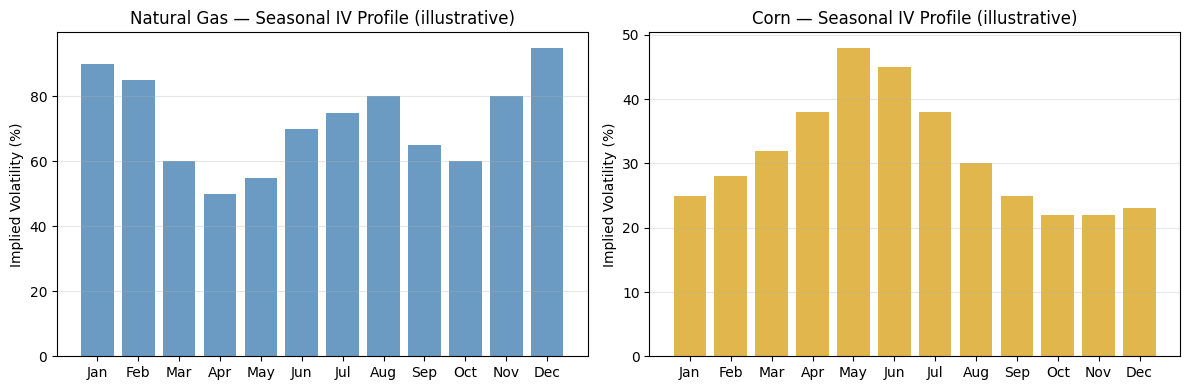

In [7]:
# Illustrative seasonal vol profile for natural gas
months = np.arange(1, 13)
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

natgas_iv = np.array([90, 85, 60, 50, 55, 70, 75, 80, 65, 60, 80, 95])
corn_iv   = np.array([25, 28, 32, 38, 48, 45, 38, 30, 25, 22, 22, 23])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(months, natgas_iv, color='steelblue', alpha=0.8)
axes[0].set_xticks(months)
axes[0].set_xticklabels(month_labels)
axes[0].set_ylabel('Implied Volatility (%)')
axes[0].set_title('Natural Gas — Seasonal IV Profile (illustrative)')
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(months, corn_iv, color='goldenrod', alpha=0.8)
axes[1].set_xticks(months)
axes[1].set_xticklabels(month_labels)
axes[1].set_ylabel('Implied Volatility (%)')
axes[1].set_title('Corn — Seasonal IV Profile (illustrative)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## 6. Greeks in Commodity Option Trading

All Greeks are computed from **Black-76** in commodity markets (using $F$ instead of $S$).

### Delta — Commodity Interpretation

$$\Delta_{call} = e^{-rT} N(d_1) \qquad \Delta_{put} = -e^{-rT} N(-d_1)$$

- Delta is expressed in **futures contracts** or **barrels / MMBtu / bushels**, depending on the contract unit
- A crude oil call with Δ = 0.50 on one 1,000-bbl futures contract = 500 bbl equivalent exposure
- **Physical producers** sell calls (delta hedge their natural long inventory)
- **Airlines / utilities** buy calls to cap fuel/energy costs (delta hedge their natural short)

### Theta — Roll Yield vs. Time Decay

In commodity options, theta interacts with the **roll yield** of the underlying futures:
- In **contango**, futures roll down toward spot → negative roll yield compounds theta for long call holders
- In **backwardation**, futures roll up → positive roll yield partially offsets theta decay on long calls

### Vega — The Vol Trade in Commodities

Commodity vega trades are common around **known events**:

| Event | Trade | Rationale |
|---|---|---|
| EIA weekly petroleum storage report | Buy straddle before, sell after | IV spikes before, crushes after |
| USDA WASDE crop report | Long straddle or strangle | Major supply/demand revision |
| OPEC meeting | Buy OTM calls before | Upside risk if production cut announced |
| Winter weather forecast | Buy natural gas calls / straddles | Demand uncertainty spikes vol |

In [8]:
def black76_greeks(F, K, T, r, sigma):
    _d1 = d1_76(F, K, T, r, sigma)
    _d2 = d2_76(F, K, T, r, sigma)
    disc = np.exp(-r * T)

    delta_c =  disc * norm.cdf(_d1)
    delta_p = -disc * norm.cdf(-_d1)
    gamma   =  disc * norm.pdf(_d1) / (F * sigma * np.sqrt(T))
    vega    =  F * disc * norm.pdf(_d1) * np.sqrt(T) / 100   # per 1% IV
    theta_c = -(F * disc * norm.pdf(_d1) * sigma / (2 * np.sqrt(T))
                + r * black76_call(F, K, T, r, sigma)) / 365
    theta_p = -(F * disc * norm.pdf(_d1) * sigma / (2 * np.sqrt(T))
                + r * black76_put(F, K, T, r, sigma)) / 365

    print(f"{'':=<55}")
    print(f"  F={F}  K={K}  T={T:.2f}yr  r={r*100:.1f}%  σ={sigma*100:.0f}%")
    print(f"{'':=<55}")
    print(f"  {'Greek':<14} {'Call':>10} {'Put':>10}")
    print(f"  {'-'*36}")
    print(f"  {'Price':<14} {black76_call(F,K,T,r,sigma):>10.4f} {black76_put(F,K,T,r,sigma):>10.4f}")
    print(f"  {'Delta':<14} {delta_c:>10.4f} {delta_p:>10.4f}")
    print(f"  {'Gamma':<14} {gamma:>10.4f} {gamma:>10.4f}")
    print(f"  {'Theta/day':<14} {theta_c:>10.4f} {theta_p:>10.4f}")
    print(f"  {'Vega/1% IV':<14} {vega:>10.4f} {vega:>10.4f}")
    print(f"{'':=<55}")

# Example: WTI crude oil option, ATM
# 1 contract = 1,000 barrels; multiply $ Greeks by 1000 for contract-level exposure
black76_greeks(
    F     = 80.00,  # front-month WTI futures price ($/bbl)
    K     = 80.00,  # strike (ATM)
    T     = 0.25,   # ~3 months to expiry
    r     = 0.05,   # risk-free rate
    sigma = 0.35,   # 35% IV (typical for crude)
)

  F=80.0  K=80.0  T=0.25yr  r=5.0%  σ=35%
  Greek                Call        Put
  ------------------------------------
  Price              5.5088     5.5088
  Delta              0.5282    -0.4594
  Gamma              0.0280     0.0280
  Theta/day         -0.0309    -0.0309
  Vega/1% IV         0.1570     0.1570


---
## 7. Convenience Yield Deep Dive

The **convenience yield** ($c$) is the implicit benefit of holding physical inventory — the option value of having the commodity available when you need it. It's not directly observable but is **implied** from the futures curve.

$$c = r + s - \frac{1}{T} \ln\!\left(\frac{F}{S}\right)$$

| Situation | Convenience Yield | Forward Curve |
|---|---|---|
| Ample inventories | Low | Contango |
| Tight inventories (supply crunch) | High | Backwardation |
| Refinery turnaround, pipeline outage | Very high | Steep backwardation |

**Why it matters for option pricing:**
- High convenience yield → futures price below spot → OTM calls on futures are cheaper than they look vs. spot price
- Producers pricing hedges must account for the curve shape, not just spot vol
- The convenience yield can spike in hours (supply disruption) — this is a key source of **jump risk** BSM ignores

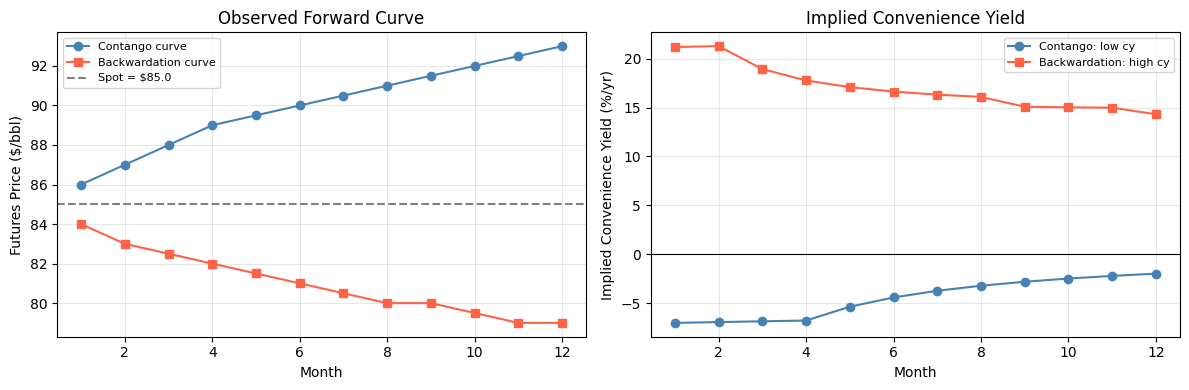

In [9]:
# Implied convenience yield from observed futures prices
S0 = 85.0   # spot crude oil ($/bbl)
r  = 0.05
s  = 0.02   # storage cost rate

# Hypothetical observed futures prices for 12 monthly contracts
T_vals   = np.arange(1, 13) / 12
F_obs_contango    = np.array([86, 87, 88, 89, 89.5, 90, 90.5, 91, 91.5, 92, 92.5, 93])
F_obs_backwardation = np.array([84, 83, 82.5, 82, 81.5, 81, 80.5, 80, 80, 79.5, 79, 79])

cy_contango     = r + s - np.log(F_obs_contango / S0) / T_vals
cy_backwardation = r + s - np.log(F_obs_backwardation / S0) / T_vals

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(np.arange(1,13), F_obs_contango,     'o-', color='steelblue', label='Contango curve')
axes[0].plot(np.arange(1,13), F_obs_backwardation,'s-', color='tomato',    label='Backwardation curve')
axes[0].axhline(S0, color='gray', linestyle='--', label=f'Spot = ${S0}')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Futures Price ($/bbl)')
axes[0].set_title('Observed Forward Curve')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(np.arange(1,13), cy_contango * 100,     'o-', color='steelblue', label='Contango: low cy')
axes[1].plot(np.arange(1,13), cy_backwardation * 100,'s-', color='tomato',    label='Backwardation: high cy')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Implied Convenience Yield (%/yr)')
axes[1].set_title('Implied Convenience Yield')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 8. Practical Commodity Hedging with Black-76

### 8.1 Producer Hedge (Short Delta)

A crude oil producer is naturally **long delta** (they own barrels in the ground). They hedge by:
1. **Selling futures** — locks in the price, eliminates all upside and downside (delta = 0 after hedge)
2. **Buying puts** — pays premium, protects the downside, keeps upside (long put = long optionality)
3. **Selling calls (costless collar)** — finances put purchase by capping upside; net delta ≈ 0

### 8.2 Consumer Hedge (Long Delta)

An airline is naturally **short delta** (they need to buy fuel). They hedge by:
1. **Buying futures** — locks in cost, eliminates upside and downside
2. **Buying calls** — caps maximum fuel cost, benefits if prices fall
3. **Buying a call spread** — cheaper than outright call; caps the hedge at a ceiling strike

### 8.3 Hedge Ratio Calculation

In [10]:
# Scenario: airline wants to hedge 10 million gallons of jet fuel over 6 months
# Using heating oil futures as a proxy (jet fuel ≈ heating oil)

F     = 2.80    # heating oil futures price ($/gallon)
K     = 2.90    # strike for OTM call (cap fuel cost at $2.90)
T     = 0.5     # 6 months
r     = 0.05
sigma = 0.40    # heating oil vol
gallons_needed = 10_000_000
contract_size  = 42_000    # 1 NYMEX heating oil contract = 42,000 gallons

_d1  = d1_76(F, K, T, r, sigma)
delta_call = np.exp(-r*T) * norm.cdf(_d1)
call_price = black76_call(F, K, T, r, sigma)

contracts_delta_neutral = gallons_needed / (delta_call * contract_size)
contracts_full_cover    = gallons_needed / contract_size
total_premium           = call_price * gallons_needed

print(f"Heating Oil Call Option: F=${F}, K=${K}, T={T}yr, σ={sigma*100:.0f}%")
print(f"  Call Price:       ${call_price:.4f}/gallon")
print(f"  Call Delta:       {delta_call:.4f}")
print()
print(f"Airline needs to hedge {gallons_needed:,} gallons")
print(f"  Full coverage contracts needed: {contracts_full_cover:.0f} contracts")
print(f"  Delta-neutral contracts needed: {contracts_delta_neutral:.0f} contracts")
print(f"  Total premium paid:            ${total_premium:,.0f}")
print()
print(f"Max fuel cost with hedge: ${K + call_price:.4f}/gallon")
print(f"Benefit if price drops:   keep savings (put is uncapped downside benefit)")

Heating Oil Call Option: F=$2.8, K=$2.9, T=0.5yr, σ=40%
  Call Price:       $0.2662/gallon
  Call Delta:       0.4944

Airline needs to hedge 10,000,000 gallons
  Full coverage contracts needed: 238 contracts
  Delta-neutral contracts needed: 482 contracts
  Total premium paid:            $2,662,267

Max fuel cost with hedge: $3.1662/gallon
Benefit if price drops:   keep savings (put is uncapped downside benefit)


---
## 9. Where Black-Scholes / Black-76 Break Down for Commodities

| Limitation | Commodity Reality | Common Fix |
|---|---|---|
| **Log-normal prices** | Commodity prices can spike 200-500% (gas crises) or near-zero (negative oil Apr 2020) | Jump-diffusion models (Merton), regime-switching |
| **Constant volatility** | Vol is seasonal, mean-reverting, and event-driven | SABR model, local vol surface, vol term structure |
| **No mean reversion** | Most commodity prices revert to long-run marginal cost | Schwartz one-factor / two-factor models |
| **Continuous trading** | Physical markets have delivery constraints, pipeline capacity limits | Real options framework |
| **European exercise only** | Many commodity options are American (early exercise for physical delivery) | Binomial trees, finite difference methods |
| **Single underlying** | Spread options (crack spread, spark spread) have two correlated underlyings | Margrabe formula, Monte Carlo |
| **Constant risk-free rate** | Minor but complicates long-dated pricing | Hull-White interest rate models |

### The April 2020 Event: When BSM Failed Completely

WTI crude settled at **−$37.63/bbl** on April 20, 2020 — a negative price. Black-76 breaks down entirely because log-normal distributions cannot accommodate negative prices. The CME had to switch to a **Bachelier (normal) model** for pricing commodity options around that event, which allows for negative underlying values.

In [11]:
# Bachelier (normal) model — handles near-zero / negative prices
def bachelier_call(F, K, T, r, sigma_normal):
    """sigma_normal is in price units ($/bbl), not percentage."""
    d = (F - K) / (sigma_normal * np.sqrt(T))
    return np.exp(-r*T) * ((F - K) * norm.cdf(d) + sigma_normal * np.sqrt(T) * norm.pdf(d))

def bachelier_put(F, K, T, r, sigma_normal):
    d = (F - K) / (sigma_normal * np.sqrt(T))
    return np.exp(-r*T) * ((K - F) * norm.cdf(-d) + sigma_normal * np.sqrt(T) * norm.pdf(d))

# Compare Black-76 vs Bachelier when futures price is very low
F_low = 5.0    # very distressed futures price
K     = 10.0
T     = 0.083  # ~1 month
r     = 0.05
sigma_pct    = 2.00   # 200% log-normal vol (extreme)
sigma_normal = 8.0    # $8/bbl normal vol

print(f"Very low futures price scenario: F=${F_low}, K=${K}")
print()
print(f"Black-76 put   (σ={sigma_pct*100:.0f}% lognormal): ${black76_put(F_low, K, T, r, sigma_pct):.4f}")
print(f"Bachelier put  (σ=${sigma_normal}/bbl normal):    ${bachelier_put(F_low, K, T, r, sigma_normal):.4f}")
print()
print("In stressed markets, Bachelier gives more sensible results")
print("because it does not require log(F/K) to be defined (F can be 0 or negative).")

Very low futures price scenario: F=$5.0, K=$10.0

Black-76 put   (σ=200% lognormal): $5.1993
Bachelier put  (σ=$8.0/bbl normal):    $4.9915

In stressed markets, Bachelier gives more sensible results
because it does not require log(F/K) to be defined (F can be 0 or negative).


---
## 10. Spread Options — Beyond Single-Commodity BSM

Commodity traders frequently trade **spread options** — options on the price difference between two related commodities. BSM cannot handle these directly.

| Spread | Components | Who trades it | Meaning |
|---|---|---|---|
| **Crack spread** | Refined product − Crude (e.g., RBOB − WTI) | Oil refiners | Refinery margin |
| **Spark spread** | Power price − Gas cost × heat rate | Power generators | Plant profitability |
| **Crush spread** | Soy meal + Soy oil − Soybeans | Soy processors | Processing margin |
| **Calendar spread** | Near-month − Far-month futures | All commodity traders | Carry / storage bet |

### Margrabe's Formula (Exchange Option)

An option to exchange asset $B$ for asset $A$ (i.e., option on spread $A - B$):

$$C = F_A \cdot N(d_1) - F_B \cdot N(d_2)$$

$$d_1 = \frac{\ln(F_A/F_B) + \frac{1}{2}\sigma_{AB}^2 T}{\sigma_{AB}\sqrt{T}} \qquad \sigma_{AB} = \sqrt{\sigma_A^2 + \sigma_B^2 - 2\rho\sigma_A\sigma_B}$$

where $\rho$ is the correlation between the two assets.

In [12]:
def margrabe(FA, FB, T, sigma_A, sigma_B, rho):
    """Exchange option: right to receive FA and deliver FB (option on spread FA - FB)."""
    sigma_AB = np.sqrt(sigma_A**2 + sigma_B**2 - 2 * rho * sigma_A * sigma_B)
    d1 = (np.log(FA / FB) + 0.5 * sigma_AB**2 * T) / (sigma_AB * np.sqrt(T))
    d2 = d1 - sigma_AB * np.sqrt(T)
    return FA * norm.cdf(d1) - FB * norm.cdf(d2), sigma_AB

# Crack spread option: refiner wants option on (RBOB gasoline - WTI crude)
# Simplified: 1 bbl crude → 0.42 bbl gasoline (42 gal/bbl)
F_rbob  = 2.50 * 42   # RBOB $/gallon × 42 = $/bbl equivalent = $105/bbl
F_wti   = 80.0         # WTI crude $/bbl
T       = 0.25
sig_rbob = 0.35
sig_wti  = 0.40

print("Crack Spread Option (RBOB - WTI, Margrabe formula)")
print(f"  RBOB equivalent = ${F_rbob:.2f}/bbl   WTI = ${F_wti:.2f}/bbl")
print(f"  Current crack spread = ${F_rbob - F_wti:.2f}/bbl")
print()
for rho in [0.3, 0.6, 0.8, 0.95]:
    price, sig_spread = margrabe(F_rbob, F_wti, T, sig_rbob, sig_wti, rho)
    print(f"  ρ={rho:.2f} → spread vol={sig_spread*100:.1f}%  option value=${price:.2f}/bbl")

Crack Spread Option (RBOB - WTI, Margrabe formula)
  RBOB equivalent = $105.00/bbl   WTI = $80.00/bbl
  Current crack spread = $25.00/bbl

  ρ=0.30 → spread vol=44.6%  option value=$26.09/bbl
  ρ=0.60 → spread vol=33.8%  option value=$25.35/bbl
  ρ=0.80 → spread vol=24.2%  option value=$25.05/bbl
  ρ=0.95 → spread vol=12.8%  option value=$25.00/bbl


---
## 11. Quick-Reference Summary

### Model Selection Guide

| Situation | Use |
|---|---|
| Equity / index option | **Black-Scholes** (with dividend yield $q$: replace $r$ with $r - q$) |
| Commodity futures option (standard) | **Black-76** |
| Very low or negative price environment | **Bachelier (normal) model** |
| Spread / exchange option | **Margrabe formula** |
| American-style commodity option | **Binomial tree or finite difference** |
| Long-dated commodity with mean reversion | **Schwartz 1-factor or 2-factor** |
| Stochastic vol / smile fitting | **SABR model** |

### Key Formulas at a Glance

```
BSM Call:     C = S·N(d1) − K·e^{−rT}·N(d2)
BSM Put:      P = K·e^{−rT}·N(−d2) − S·N(−d1)

Black-76 Call: C = e^{−rT}·[F·N(d1) − K·N(d2)]   ← standard for commodity options
Black-76 Put:  P = e^{−rT}·[K·N(−d2) − F·N(−d1)]

Forward curve: F = S·e^{(r + s − c)·T}
  s = storage cost rate
  c = convenience yield (implied from market futures prices)

Spread vol:   σ_AB = √(σ_A² + σ_B² − 2ρσ_Aσ_B)

Put-Call Parity (futures): C − P = e^{−rT}·(F − K)
```

### The 5 Things BSM Gets Wrong in Commodities

```
1. Assumes log-normal → misses jump risk (supply shocks, geopolitical events)
2. Assumes constant vol → misses seasonality and vol mean-reversion
3. Assumes GBM → ignores commodity price mean-reversion to marginal cost
4. European exercise only → misses early exercise premium for American options
5. Single underlying → can't handle spread options without extensions (Margrabe)
```